In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

flights = pd.read_csv("../data/cleaned/cleaned_flights.csv")

In [11]:
import statsmodels.formula.api as smf

logit_model = smf.logit("delayed_15 ~ departure_hour + C(carrier_code) + C(day_of_week) + C(month) + C(origin_airport)", data=flights).fit()

Optimization terminated successfully.
         Current function value: 0.455656
         Iterations 6


In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Model 1",
        "Linear Model 2",
        "Logistic Model"
    ],
    "Response Variable": [
        "Departure Delay",
        "Departure Delay",
        "Delayed 15+"
    ],
    "Predictors": [
        "Departure Hour",
        "Hour + Airline + Day + Month + Airport",
        "Hour + Airline + Day + Month + Airport"
    ],
    "Metric": [
        "R^2",
        "R^2",
        "Pseudo R^2"
    ],
    "Fit Statistic": [
        0.001,
        0.008,
        0.019
    ]
})

comparison

,Model,Response Variable,Predictors,Metric,Fit Statistic
0,Linear Model 1,Departure Delay,Departure Hour,R^2,0.001
1,Linear Model 2,Departure Delay,Hour + Airline + Day + Month + Airport,R^2,0.008
2,Logistic Model,Delayed 15+,Hour + Airline + Day + Month + Airport,Pseudo R^2,0.019


The first model shows that departure hour alone does not explain much of the variation in departure delays ($R^2 = 0.001$). Adding airline, day of week, month, and airport improves the model ($R^2 = 0.008$), showing that these factors help explain delays. The logistic regression model had a pseudo $R^2$ of 0.019, suggesting that these variables are somewhat better at predicting whether a flight will be delayed by at least 15 minutes than predicting the exact length of the delay.

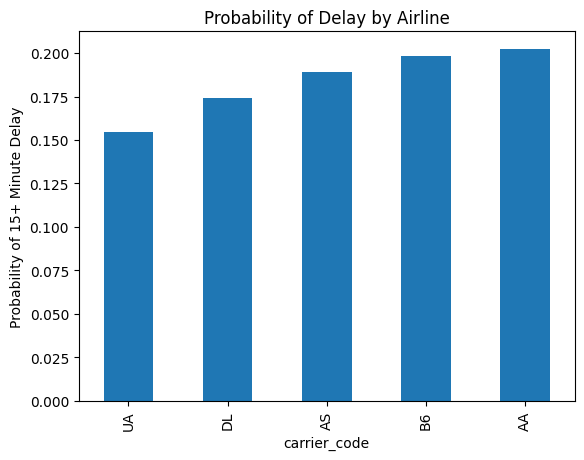

In [13]:
prob_delay = (flights.groupby("carrier_code")["delayed_15"].mean().sort_values())

prob_delay.plot(kind="bar")

plt.ylabel("Probability of 15+ Minute Delay")
plt.title("Probability of Delay by Airline")

plt.show()

United Airlines exhibited the lowest probability of a 15 minute departure delay, while American Airlines exhibited the highest probability among the airlines included in this study.

In [14]:
odds_df = pd.DataFrame({
    "Coefficient": logit_model.params,
    "Odds Ratio": np.exp(logit_model.params)
})

odds_df

,Coefficient,Odds Ratio
Intercept,-1.938449,0.143927
C(carrier_code)[T.AS],-0.110432,0.895447
C(carrier_code)[T.B6],-0.099491,0.905298
C(carrier_code)[T.DL],-0.207529,0.812590
C(carrier_code)[T.UA],-0.397195,0.672203
C(day_of_week)[T.Monday],-0.020757,0.979457
C(day_of_week)[T.Saturday],-0.137629,0.871421
C(day_of_week)[T.Sunday],0.105909,1.111721
C(day_of_week)[T.Thursday],0.012720,1.012802
C(day_of_week)[T.Tuesday],-0.304339,0.737611


Odds ratios were calculated to make the logistic regression results easier to interpret. An odds ratio greater than 1 indicates increased delay risk, while an odds ratio less than 1 indicates decreased delay risk relative to the reference.

The odds ratio for departure hour was 1.042, indicating that each additional hour later in the day increases the odds of a flight being delayed by at least 15 minutes by about 4.2%. Relative to American Airlines, United Airlines had substantially lower odds of experiencing a delay (0.67). Sunday flights had around 11% higher odds of delay than Friday flights, while Tuesday flights had about 26% lower odds. July and December have the highest delay risk, with odds ratios of 1.51 and 1.55, respectively, compared to January. Airport effects were small, with SFO showing around 5% higher odds of delay than LAX and SAN showing 2.5% lower odds of delay than LAX.